In [1]:
import cv2
import numpy as np
import os

In [ ]:
import cv2
import numpy as np

def preprocess_bender_image(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    blurred = cv2.medianBlur(img, 3)


    binary = cv2.adaptiveThreshold(
        blurred,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV,
        blockSize=15, 
        C=12         
    )


    min_component_area = 25 

    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(binary, connectivity=8)
    filtered = np.zeros_like(binary) 

    for i in range(1, num_labels):
        area = stats[i, cv2.CC_STAT_AREA]

        if area >= min_component_area:
            filtered[labels == i] = 255 

    return img, filtered

In [3]:
import os
input_folder = "Dataset\\Raw_images"
output_folder = "Dataset\\Preprocessed"



# loop through images 1 to 89
for i in range(1, 90):
    image_name = f"{i}.jpg"   # change extension if needed
    input_path = os.path.join(input_folder, image_name)

    # skip if file doesn't exist
    if not os.path.exists(input_path):
        print(f"Skipping {image_name} (not found)")
        continue

    original, processed = preprocess_bender_image(input_path)

    output_path = os.path.join(output_folder, f"{i}.jpg")

    cv2.imwrite(output_path, processed)

print("Processing complete!")

KeyboardInterrupt: 

In [ ]:
import matplotlib.pyplot as plt

def validate_preprocessing(image_path):
    original, binary = preprocess_bender_image(image_path)
    
    fig, axes = plt.subplots(1, 2, figsize=(20, 10))
    axes[0].imshow(original, cmap='gray')
    axes[0].set_title('Original Scan')
    axes[1].imshow(binary, cmap='gray')
    axes[1].set_title('After Processing')
    plt.show()
    

In [ ]:
# import cv2
# import numpy as np
# import os
# import math
# import mahotas



# class TemplateProcessor:
#     def __init__(self, template_dir):
#         self.template_dir = template_dir
#         self.templates = {}
#         self.template_features = {}
    
#     def load_templates(self):
#         """Load all template images"""
#         template_files = sorted(os.listdir(self.template_dir))
        
#         for filename in template_files:
#             if filename.endswith(('.png', '.jpg', '.jpeg')):
#                 template_name = os.path.splitext(filename)[0]
#                 path = os.path.join(self.template_dir, filename)
                

#                 _, binary = preprocess_bender_image(path)
                
#                 contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
                
#                 if contours:
#                     main_contour = max(contours, key=cv2.contourArea)
                    
#                     self.templates[template_name] = {
#                         'image': binary,
#                         'contour': main_contour,
#                         'filename': filename
#                     }
                    
#         print(f"Loaded {len(self.templates)} templates")
#         return self.templates
    
#     def extract_template_features(self):
#         for name, template in self.templates.items():
#             contour = template['contour']
            
#             # 1. Hu Moments (rotation, scale, translation invariant)
#             moments = cv2.moments(contour)
#             hu_moments = cv2.HuMoments(moments).flatten()
            
#             # 2. Zernike Moments 
#             img = template['image']

#             h, w = img.shape
#             radius = min(h, w) // 2

#             zernike_moments = mahotas.features.zernike_moments(
#                 img,
#                 radius=radius,
#                 degree=8
#             )            
#             fourier_descriptors = self.calculate_fourier_descriptors(contour, num_descriptors=20)
            
#             area = cv2.contourArea(contour)
#             perimeter = cv2.arcLength(contour, True)
#             hull = cv2.convexHull(contour)
#             hull_area = cv2.contourArea(hull)
#             solidity = area / hull_area if hull_area > 0 else 0
            
#             x, y, w, h = cv2.boundingRect(contour)
#             aspect_ratio = w / h if h > 0 else 0
            
#             self.template_features[name] = {
#                 'hu_moments': hu_moments,
#                 'zernike_moments': zernike_moments,
#                 'fourier_descriptors': fourier_descriptors,
#                 'area': area,
#                 'perimeter': perimeter,
#                 'solidity': solidity,
#                 'aspect_ratio': aspect_ratio,
#                 'bounding_box': (x, y, w, h)
#             }
        
#         return self.template_features
    

    
#     def calculate_fourier_descriptors(self, contour, num_descriptors=20):
#         contour_complex = contour.reshape(-1, 2)
#         complex_coords = contour_complex[:, 0] + 1j * contour_complex[:, 1]
        
#         fourier = np.fft.fft(complex_coords)
        
#         descriptors = fourier[1:num_descriptors+1] / fourier[0]
        
#         descriptors_magnitude = np.abs(descriptors)
        
#         return descriptors_magnitude
    
#     def save_template_features(self, output_path):
#         import pickle
        
#         with open(output_path, 'wb') as f:
#             pickle.dump({
#                 'templates': self.templates,
#                 'features': self.template_features
#             }, f)
        
#         print(f"Template features saved to {output_path}")

In [ ]:
# template_processor = TemplateProcessor('Dataset\\templates')
# templates = template_processor.load_templates()
# features = template_processor.extract_template_features()
# template_processor.save_template_features('Dataset\\templates_Preprocessed\\template_features.pkl')

# import matplotlib.pyplot as plt

# fig, axes = plt.subplots(3, 3, figsize=(12, 10))
# for idx, (name, template) in enumerate(templates.items()):
#     row = idx // 3
#     col = idx % 3
#     axes[row, col].imshow(template['image'], cmap='gray')
#     axes[row, col].set_title(f'Template {name}')
#     axes[row, col].axis('off')

# plt.tight_layout()
# plt.show()

In [2]:

import os
import json
import pandas as pd
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer
import re



def clean_gestalt_string(s):
    if not isinstance(s, str):
        return []
    import re
    s = re.sub(r'[\-\–\—]', ',', s)         
    s = s.replace('/', ',')
    parts = [p.strip() for p in s.split(',')]
    return [p for p in parts if p]
class AnnotationAnalyzer:
    def __init__(self, csv_path, output_dir='visualizations'):
        self.csv_path = csv_path
        self.df = None
        self.feature_distributions = {}
        self.output_dir = output_dir
        os.makedirs(self.output_dir, exist_ok=True)

    def load_annotations(self):
        """Load CSV annotations"""
        self.df = pd.read_csv(self.csv_path, encoding='utf-8-sig', on_bad_lines='skip')

        print(f"Dataset shape: {self.df.shape}")
        print(f"Columns: {list(self.df.columns)}")
        print("\nFirst few rows:")
        print(self.df.head())

        missing_summary = self.df.isna().sum().to_dict()
        print("\nMissing values per column:")
        for col, miss in missing_summary.items():
            if miss > 0:
                print(f"  {col}: {miss} ({miss / len(self.df):.1%})")

        return self.df




    def analyze_feature_distributions(self):
        gestalt_col = 'Gestalt Changes'               


        self.df[gestalt_col] = self.df[gestalt_col].apply(clean_gestalt_string)


        mlb_gestalt = MultiLabelBinarizer()
        gestalt_encoded = mlb_gestalt.fit_transform(self.df[gestalt_col])
        gestalt_df = pd.DataFrame(gestalt_encoded, columns=mlb_gestalt.classes_, index=self.df.index)
        gestalt_df = gestalt_df.add_prefix('gestalt_')  

        
        single_cols = {
            'Sequence': 'sequence',
            'Drawing Position': 'drawing_position',
            'Distance Between Drawings': 'distance_between',
            'Contact or Collision': 'contact_collision',
            'Margin Usage': 'margin_usage',
            'Paper Position Change': 'paper_position_change'
        }


        single_df = self.df[['Case Number'] + list(single_cols.keys())].copy()
        single_df.rename(columns=single_cols, inplace=True)

        self.full_labels = pd.concat([single_df, gestalt_df], axis=1)


        print("\nSingle choice distributions:")
        for col in single_cols.values():
            print(f"\n{col}:")
            print(self.full_labels[col].value_counts(dropna=False))

        print("\nGestalt binary indicator frequencies:")
        gestalt_cols = [c for c in self.full_labels.columns if c.startswith('gestalt_')]
        for gcol in gestalt_cols:
            count = self.full_labels[gcol].sum()
            print(f"  {gcol}: {count} ({count/len(self.full_labels)*100:.1f}%)")

        print("\nGeneral observation binary indicator frequencies:")
        obs_cols = [c for c in self.full_labels.columns if c.startswith('obs_')]
        for ocol in obs_cols:
            count = self.full_labels[ocol].sum()
            print(f"  {ocol}: {count} ({count/len(self.full_labels)*100:.1f}%)")

        self.gestalt_column_names = mlb_gestalt.classes_
        return self.full_labels

    def identify_imbalanced_classes(self, threshold=0.10):
        imbalanced_features = {}

        for feature_name, distribution in self.feature_distributions.items():
            total = distribution['total']
            imbalanced_classes = []

            for class_name, count in distribution['counts'].items():
                if class_name == 'Missing':
                    continue

                proportion = count / total
                if proportion < threshold:
                    imbalanced_classes.append({
                        'class': class_name,
                        'count': count,
                        'proportion': proportion
                    })

            if imbalanced_classes:
                imbalanced_features[feature_name] = imbalanced_classes

        print("\nImbalanced Classes (less than {:.1%} of samples):".format(threshold))
        if not imbalanced_features:
            print("  None detected.")

        for feature, classes in imbalanced_features.items():
            print(f"\n{feature}:")
            for cls in classes:
                print(f"  {cls['class']}: {cls['count']} samples ({cls['proportion']*100:.1f}%)")

        return imbalanced_features

    def create_validation_split(self, train_ratio=0.7, val_ratio=0.15, test_ratio=0.15,
                                stratify_by=None, random_state=42):

        assert abs(train_ratio + val_ratio + test_ratio - 1.0) < 0.001

        id_col = self.df.columns[0]
        image_ids = self.df[id_col].values

        stratify_labels = None
        if stratify_by is not None and stratify_by in self.df.columns:
            valid_mask = self.df[stratify_by].notna()
            if valid_mask.sum() < len(self.df):
                print(f" Stratification on '{stratify_by}' drops {len(self.df) - valid_mask.sum()} samples with missing labels.")
            ids_valid = self.df.loc[valid_mask, id_col].values
            labels_valid = self.df.loc[valid_mask, stratify_by].values

            train_ids, temp_ids, train_labels, temp_labels = train_test_split(
                ids_valid,
                labels_valid,
                train_size=train_ratio,
                random_state=random_state,
                stratify=labels_valid
            )

            val_ratio_adjusted = val_ratio / (val_ratio + test_ratio)
            val_ids, test_ids = train_test_split(
                temp_ids,
                train_size=val_ratio_adjusted,
                random_state=random_state,
                stratify=temp_labels
            )

            all_split_ids = set(train_ids) | set(val_ids) | set(test_ids)
            remaining_ids = set(image_ids) - all_split_ids
            if remaining_ids:
                print(f"[Info] {len(remaining_ids)} samples were not included in splits due to missing stratification labels. "
                      f"You may choose to assign them to train/val/test manually or use a different strat column.")

        else:
            # No stratification
            train_ids, temp_ids = train_test_split(
                image_ids,
                train_size=train_ratio,
                random_state=random_state
            )
            val_ratio_adjusted = val_ratio / (val_ratio + test_ratio)
            val_ids, test_ids = train_test_split(
                temp_ids,
                train_size=val_ratio_adjusted,
                random_state=random_state
            )

        splits = {
            'train': train_ids.tolist(),
            'val': val_ids.tolist(),
            'test': test_ids.tolist()
        }

        print("\nSplit Distribution:")
        print(f"Train: {len(train_ids)} samples ({len(train_ids)/len(image_ids)*100:.1f}%)")
        print(f"Validation: {len(val_ids)} samples ({len(val_ids)/len(image_ids)*100:.1f}%)")
        print(f"Test: {len(test_ids)} samples ({len(test_ids)/len(image_ids)*100:.1f}%)")

        if stratify_by is not None and stratify_by in self.df.columns:
            self.verify_stratification(splits, stratify_by)

        splits_path = os.path.join(self.output_dir, 'data_splits.json')
        with open(splits_path, 'w', encoding='utf-8') as f:
            json.dump(splits, f, ensure_ascii=False, indent=2)
        print(f"Splits saved to {splits_path}")

        return splits

    def verify_stratification(self, splits, feature_name):
        """Verify that class distribution is preserved in splits"""
        id_col = self.df.columns[0]
        df_indexed = self.df.set_index(id_col)

        print(f"\nClass distribution for '{feature_name}':")
        print("-" * 50)

        for split_name, split_ids in splits.items():
            split_df = df_indexed.loc[split_ids]
            value_counts = split_df[feature_name].value_counts(dropna=False, normalize=True)

            print(f"\n{split_name.capitalize()} split ({len(split_ids)} samples):")
            for value, proportion in value_counts.items():
                print(f"  {value}: {proportion*100:.1f}%")

    def visualize_distributions(self):
        """Create visualizations of feature distributions"""
        for feature_name, distribution in self.feature_distributions.items():
            counts = distribution['counts']
            labels = list(counts.keys())
            values = list(counts.values())

            plt.figure(figsize=(max(10, 0.25 * len(labels)), 6))
            bars = plt.bar(range(len(labels)), values)

            plt.xticks(range(len(labels)), labels, rotation=45, ha='right')
            plt.title(f'Distribution of {feature_name}', fontsize=12)
            plt.ylabel('Count')
            plt.tight_layout()

            for bar in bars:
                height = bar.get_height()
                plt.text(bar.get_x() + bar.get_width()/2., height,
                         f'{int(height)}', ha='center', va='bottom')

            out_path = os.path.join(self.output_dir, f"{feature_name.replace(' ', '_')}_distribution.png")
            plt.savefig(out_path, dpi=150, bbox_inches='tight')
            plt.close()

        print(f"Visualizations saved to {self.output_dir}/")






In [5]:
analyzer = AnnotationAnalyzer(csv_path='Dataset//bender.csv', output_dir='visualizations')

df = analyzer.load_annotations()

distributions = analyzer.analyze_feature_distributions()

imbalanced = analyzer.identify_imbalanced_classes(threshold=0.10)

splits = analyzer.create_validation_split(
    train_ratio=0.7,
    val_ratio=0.15,
    test_ratio=0.15,
    stratify_by='Sequence',   
    random_state=42
)

analyzer.visualize_distributions()



Dataset shape: (89, 16)
Columns: ['Case Number', 'الاسم', 'Gender', 'Grade', 'Age', 'Sequence', 'Drawing Position', 'Distance Between Drawings', 'Contact or Collision', 'Margin Usage', 'Paper Position Change', 'Gestalt Changes', 'ملاحظات دالة بشكل عام', 'التصنيفات المرضية', 'التعليق العام', 'Unnamed: 15']

First few rows:
   Case Number                       الاسم Gender                 Grade  Age  \
0            1         ياسين محمود علي حسن   Male  4th Grade Elementary    9   
1            2         عمرو احمد محمد فتحي   Male  4th Grade Elementary    9   
2            3  محمد سيد البدري عبد المطلب   Male  4th Grade Elementary    9   
3            4           عدي هاني سيد محمد   Male  4th Grade Elementary   10   
4            5        عمر حاتم عمر الفاروق   Male  4th Grade Elementary   11   

                Sequence Drawing Position Distance Between Drawings  \
0  Disorganized Sequence               No           0.75 to 1.25 cm   
1     Organized Sequence               No           0

Extract Bounding Boxes

In [34]:
# from ultralytics import YOLO
#
# yaml_text = """
# path: Dataset
#
# train: train
# val: val
#
# nc: 9
# names:
#   0: figure_0
#   1: figure_1
#   2: figure_2
#   3: figure_3
#   4: figure_4
#   5: figure_5
#   6: figure_6
#   7: figure_7
#   8: figure_8
# """
#
# with open("dataset.yaml", "w") as f:
#     f.write(yaml_text)
#
# print("dataset.yaml written.")
#
# model = YOLO("yolov8n.pt")
#
# model.train(
#     data        = "dataset.yaml",
#     epochs      = 50,
#     imgsz       = 640,
#     batch       = 8,
#     patience    = 20, # early stopping
#     optimizer   = "AdamW",
#     lr0         = 1e-3,
#     augment     = True,
#     # augmentation for grayscale scans:
#     hsv_h       = 0.0, # no hue shift (grayscale)
#     hsv_s       = 0.0, # no saturation shift
#     hsv_v       = 0.3, # slight brightness variation
#     degrees     = 10,  # small rotation augmentation
#     translate   = 0.1,
#     scale       = 0.3,
#     project     = 'bender',
#     fliplr      = 0.0, # Bender figures are NOT flip-invariant
#     exist_ok    = True
# )

dataset.yaml written.
New https://pypi.org/project/ultralytics/8.4.49 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.48  Python-3.12.10 torch-2.11.0+cpu CPU (AMD Ryzen 5 5600H with Radeon Graphics)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset.yaml, degrees=10, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.0, hsv_s=0.0, hsv_v=0.3, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5, 6, 7, 8])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x000002111BCAF8F0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.

In [35]:
FIGURE_NAMES = ["0","1","2","3","4","5","6","7","8"]

def extract_bender_figures(image_path,
                           model_path="runs/detect/bender/train/weights/best.pt",
                           conf_threshold=0.3,
                           padding=10):

    model = YOLO(model_path)
    img   = cv2.imread(image_path)
    if img is None:
        raise FileNotFoundError(f"Could not load image: {image_path}")

    h, w = img.shape[:2]

    preds = model.predict(
        source    = image_path,
        conf      = conf_threshold,
        iou       = 0.4,          # NMS IoU threshold
        imgsz     = 640,
        verbose   = False
    )[0]                          # single image → first result

    boxes_out   = []
    classes_out = []
    names_out   = []
    scores_out  = []
    crops_out   = []

    if preds.boxes is not None:
        xyxy    = preds.boxes.xyxy.cpu().numpy().astype(int)
        cls_ids = preds.boxes.cls.cpu().numpy().astype(int)
        confs   = preds.boxes.conf.cpu().numpy()

        # sort detections left-to-right, top-to-bottom
        order = sorted(range(len(xyxy)),
                       key=lambda i: (xyxy[i][1] // 100, xyxy[i][0]))

        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) if len(img.shape) == 3 else img

        for i in order:
            x1, y1, x2, y2 = xyxy[i]
            cls             = int(cls_ids[i])
            conf            = float(confs[i])

            # apply padding (clamp to image bounds)
            x1p = max(0,  x1 - padding)
            y1p = max(0,  y1 - padding)
            x2p = min(w,  x2 + padding)
            y2p = min(h,  y2 + padding)

            crop = gray[y1p:y2p, x1p:x2p]

            boxes_out.append((x1p, y1p, x2p, y2p))
            classes_out.append(cls)
            names_out.append(FIGURE_NAMES[cls] if cls < len(FIGURE_NAMES) else str(cls))
            scores_out.append(conf)
            crops_out.append(crop)

    print(f"Detected {len(boxes_out)} / 9 figures in {os.path.basename(image_path)}")

    return {
        "boxes"  : boxes_out,
        "classes": classes_out,
        "names"  : names_out,
        "scores" : scores_out,
        "crops"  : crops_out
    }

In [36]:
import matplotlib.patches as patches

FIGURE_COLORS = {
    "0": "red",   "1": "orange", "2": "gold",   "3": "lime",
    "4": "cyan",  "5": "blue",   "6": "violet",  "7": "magenta", "8": "white"
}

def visualize_detections(image_path, results_dict):
    img     = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    fig, ax = plt.subplots(1, 1, figsize=(14, 10))
    ax.imshow(img_rgb)

    for box, name, score in zip(results_dict["boxes"],
                                results_dict["names"],
                                results_dict["scores"]):
        x1, y1, x2, y2 = box
        color = FIGURE_COLORS.get(name, "lime")
        rect  = patches.Rectangle(
            (x1, y1), x2 - x1, y2 - y1,
            linewidth=2, edgecolor=color, facecolor="none"
        )
        ax.add_patch(rect)
        ax.text(x1, y1 - 5, f"Fig {name}  {score:.2f}",
                color=color, fontsize=9, fontweight="bold",
                bbox=dict(facecolor="black", alpha=0.4, pad=1))

    ax.set_title(f"Bender Figures Detected: {len(results_dict['boxes'])} / 9  |  {os.path.basename(image_path)}")
    ax.axis("off")
    plt.tight_layout()
    plt.show()

    # 3×3 grid of crops
    crops = results_dict["crops"]
    if crops:
        fig2, axes = plt.subplots(3, 3, figsize=(10, 10))
        for idx, ax2 in enumerate(axes.flat):
            if idx < len(crops):
                ax2.imshow(crops[idx], cmap="gray")
                ax2.set_title(f"Figure {results_dict['names'][idx]}  ({results_dict['scores'][idx]:.2f})")
            ax2.axis("off")
        plt.tight_layout()
        plt.show()

Found 10 test images

Detected 9 / 9 figures in 80.jpg
Detected 9 / 9 figures in 81.jpg
Detected 9 / 9 figures in 82.jpg
Detected 9 / 9 figures in 83.jpg
Detected 10 / 9 figures in 84.jpg
Detected 9 / 9 figures in 85.jpg
Detected 9 / 9 figures in 86.jpg
Detected 9 / 9 figures in 87.jpg
Detected 9 / 9 figures in 88.jpg
Detected 8 / 9 figures in 89.jpg


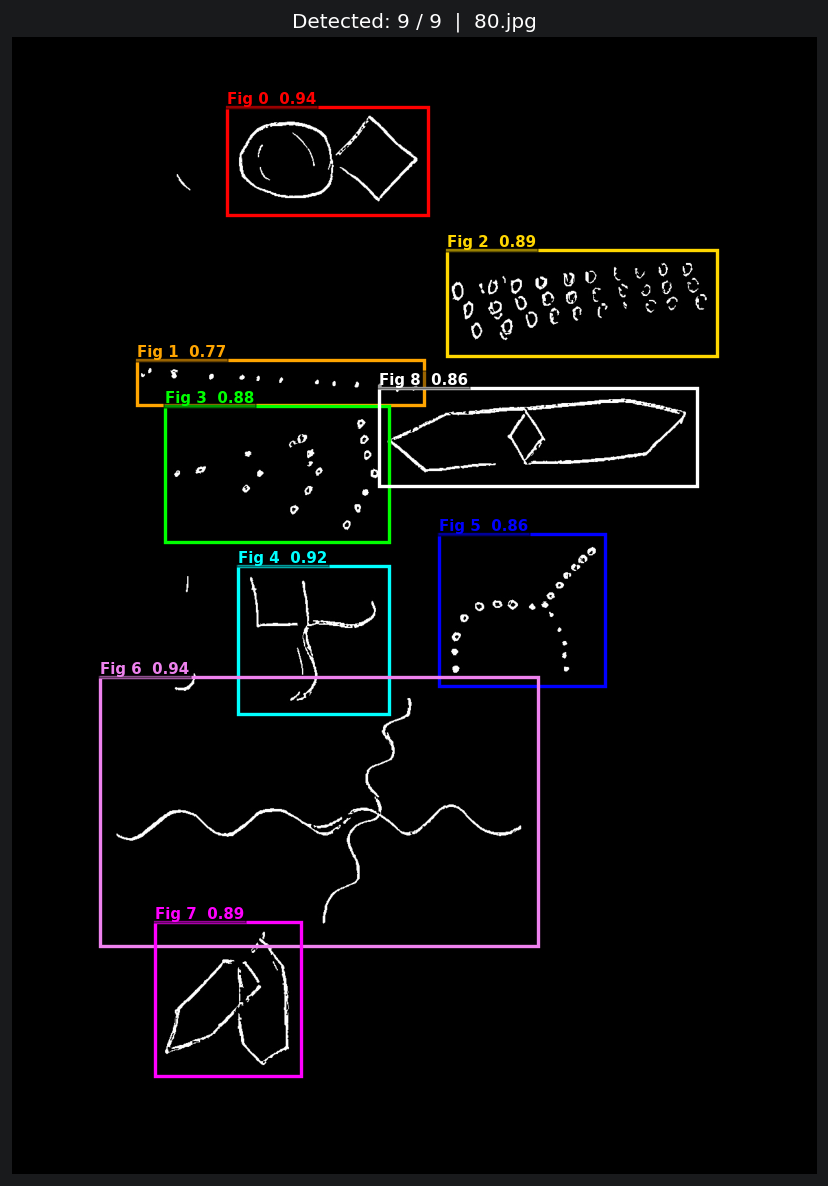

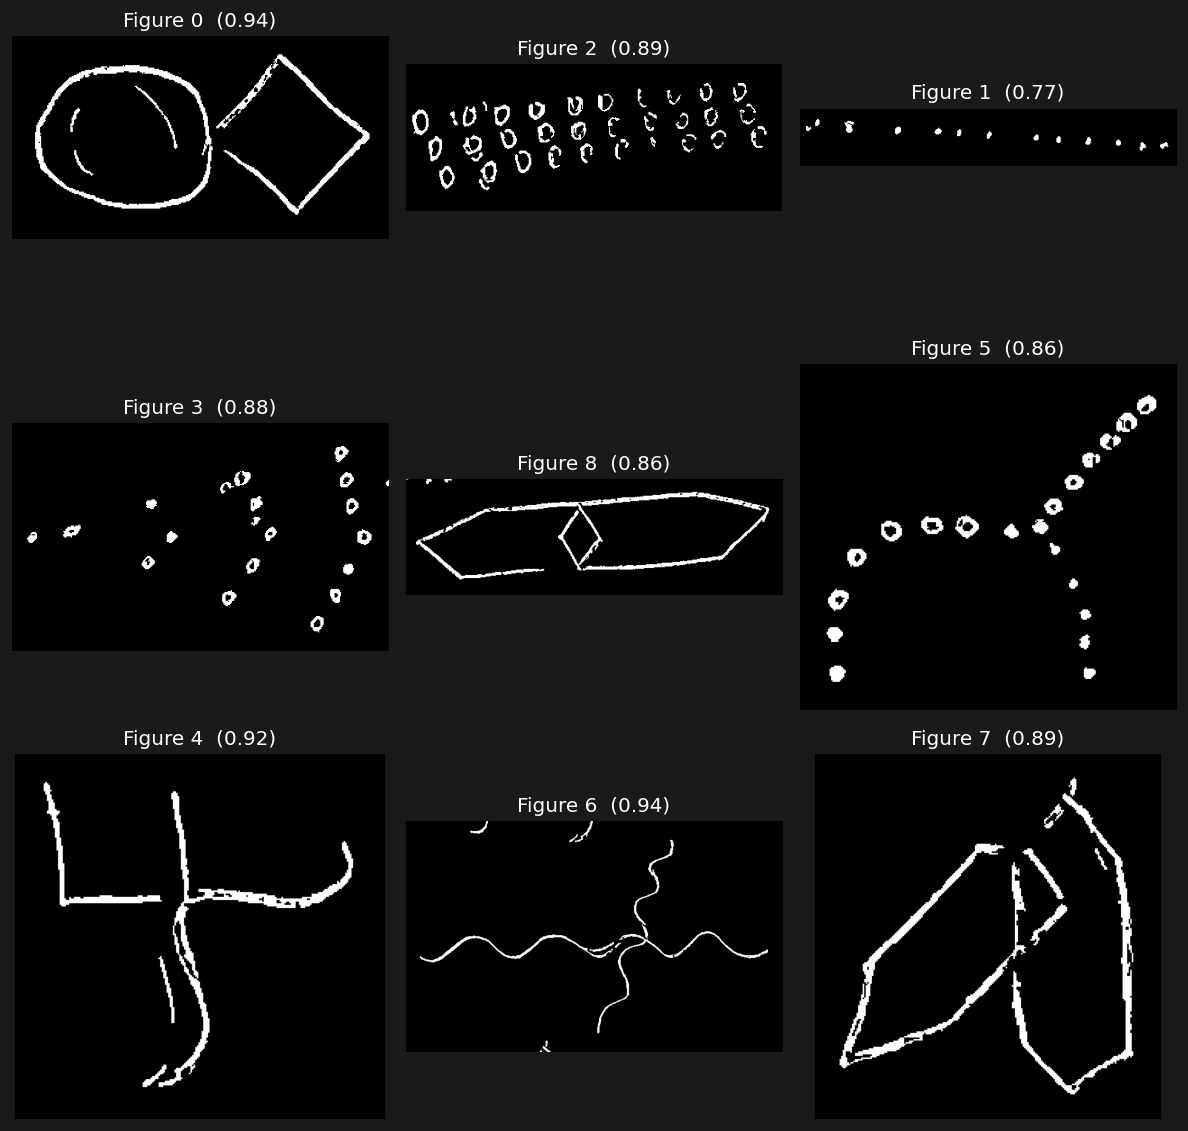

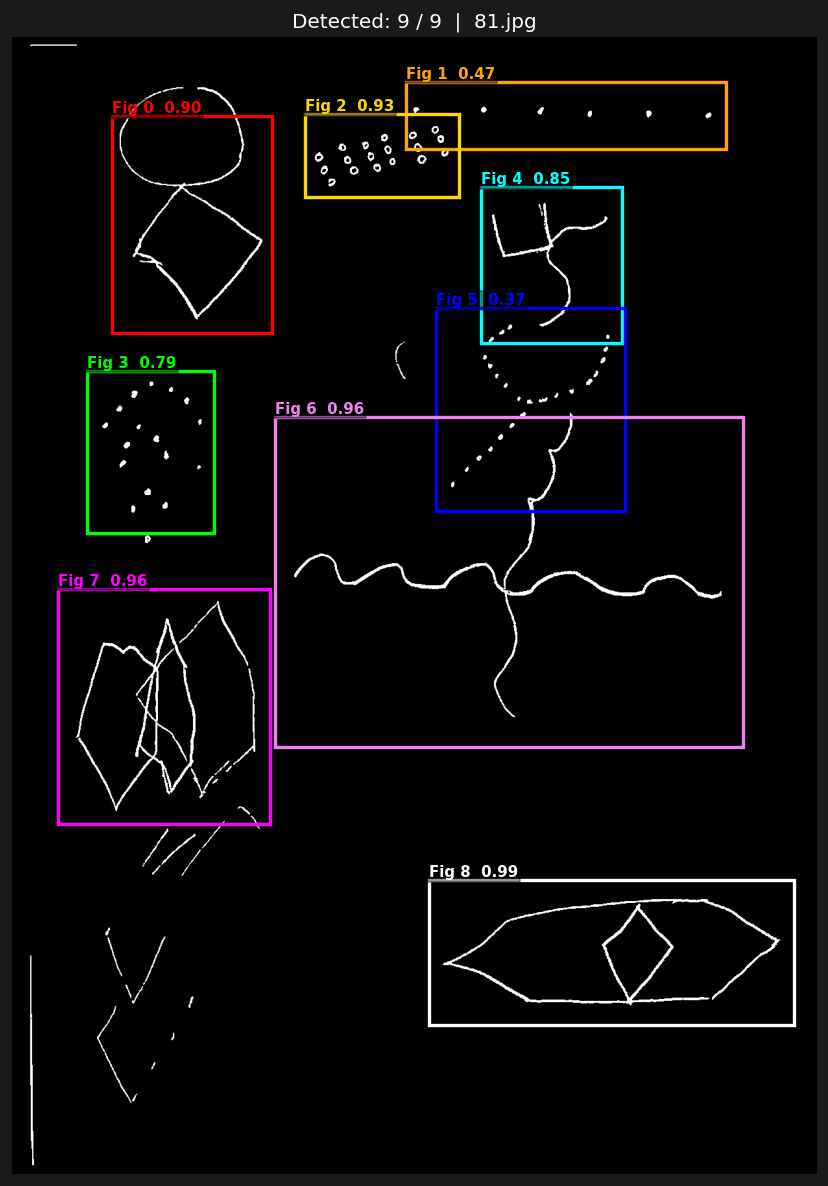

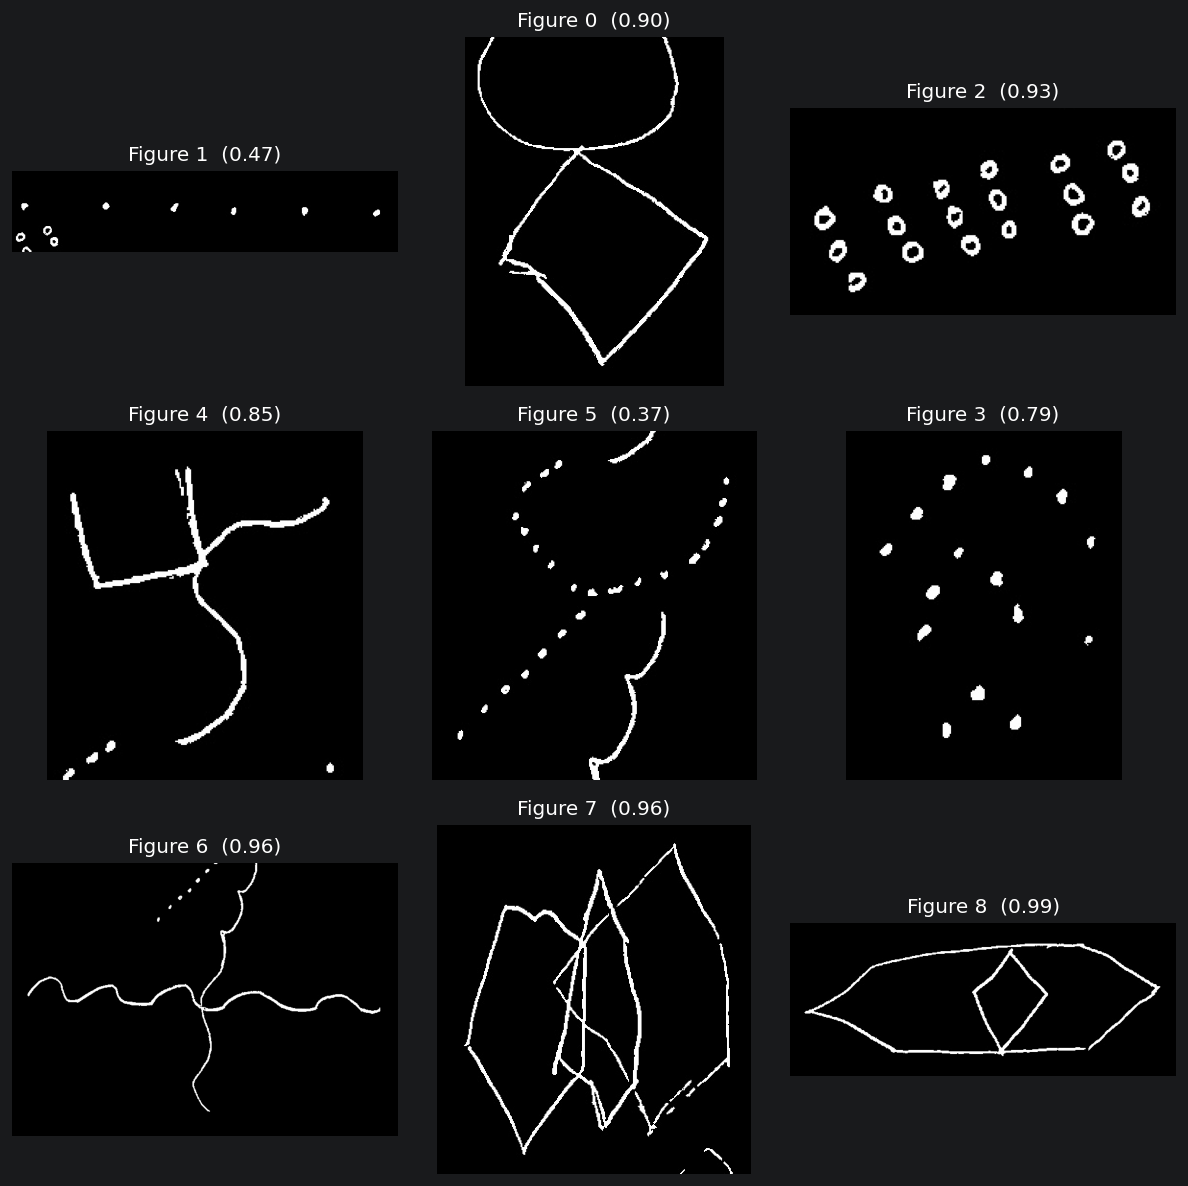

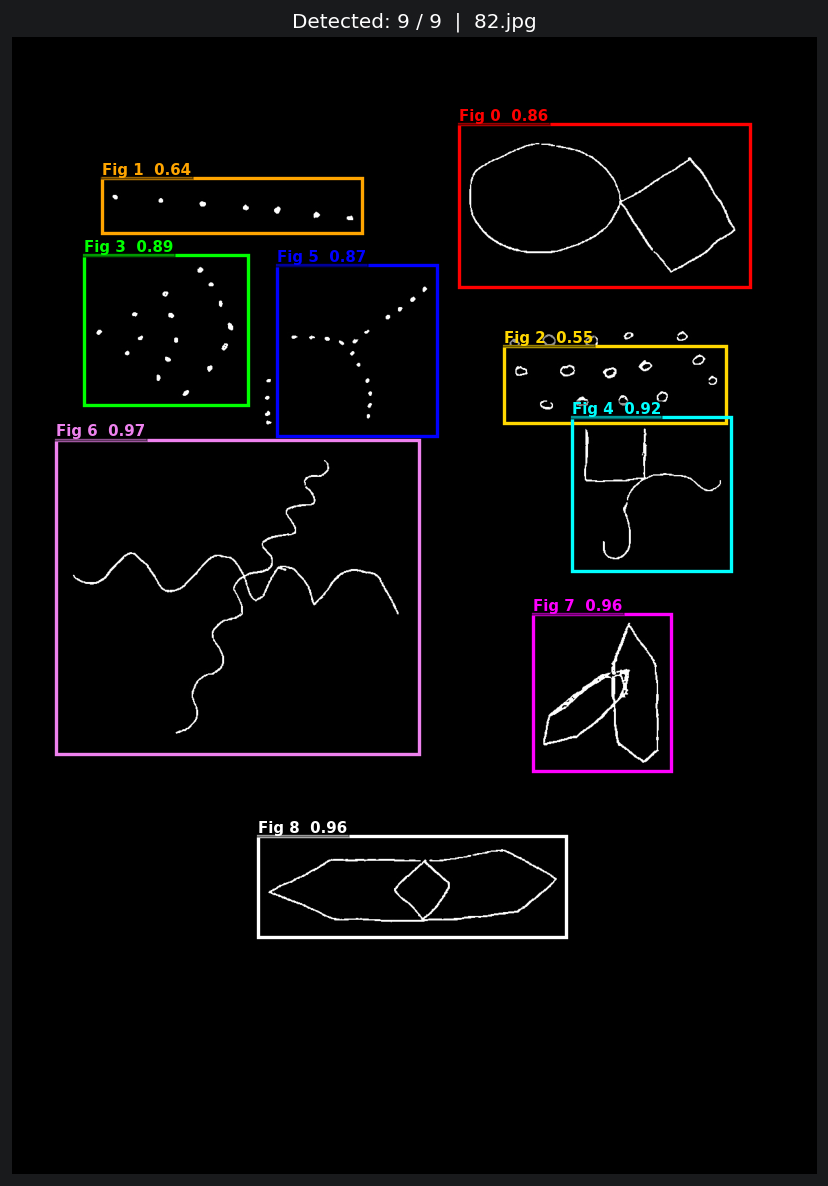

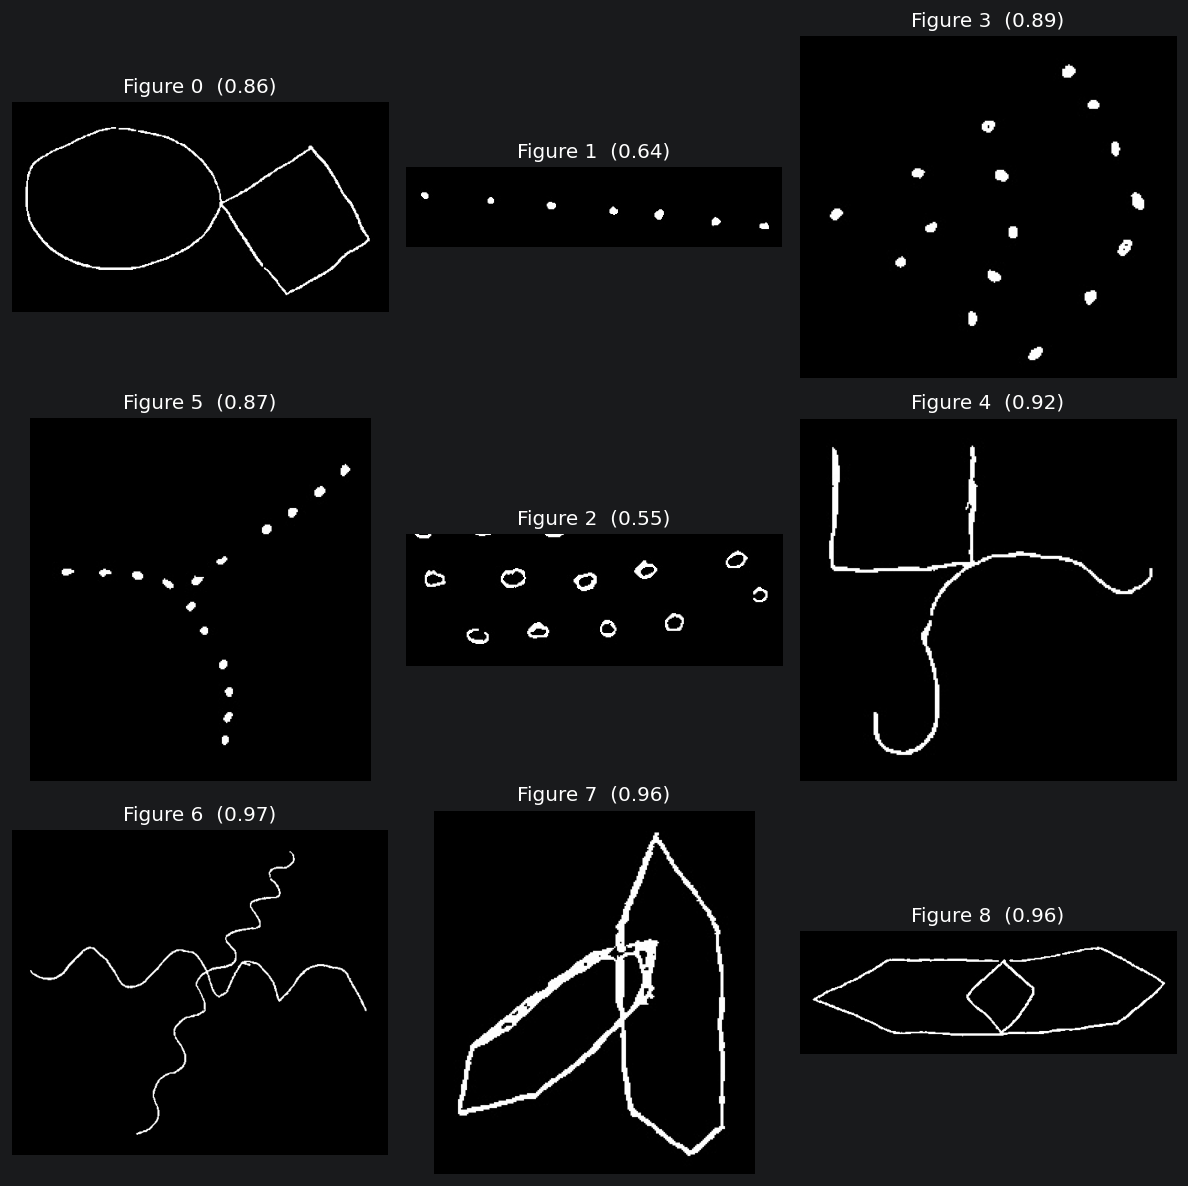

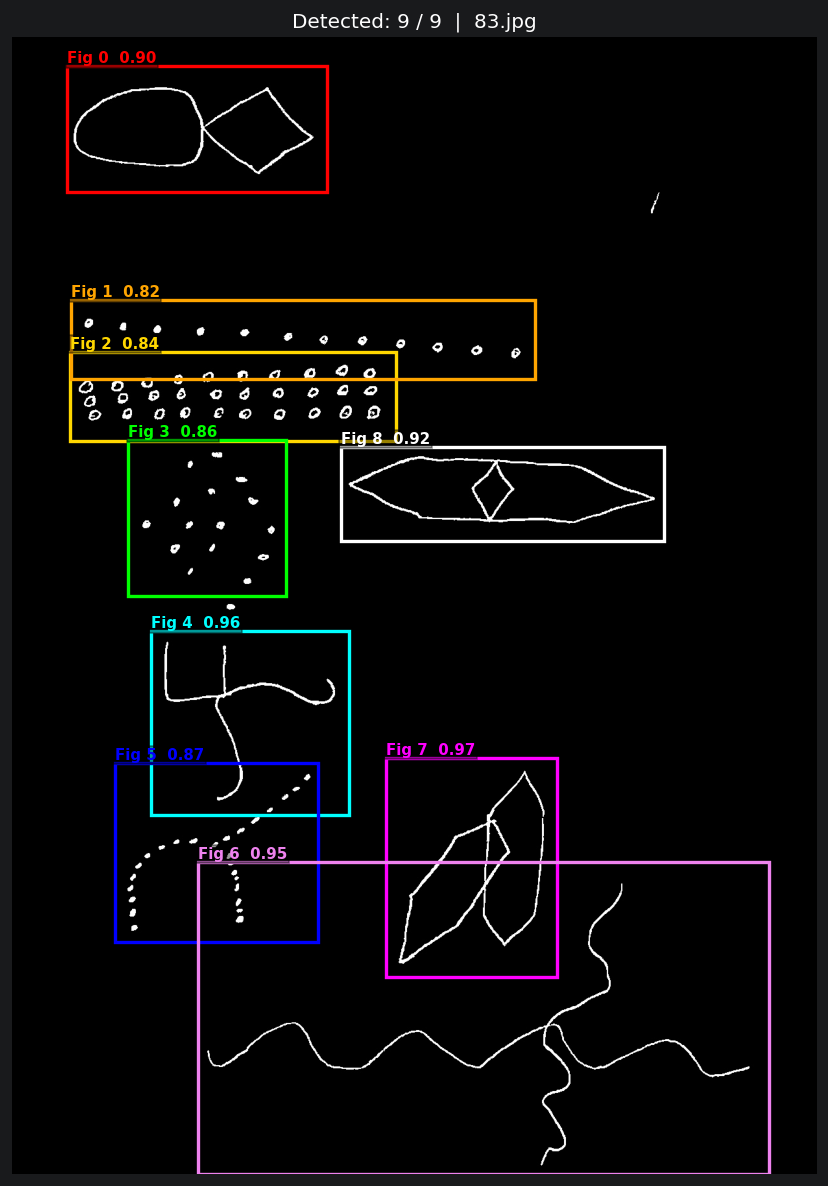

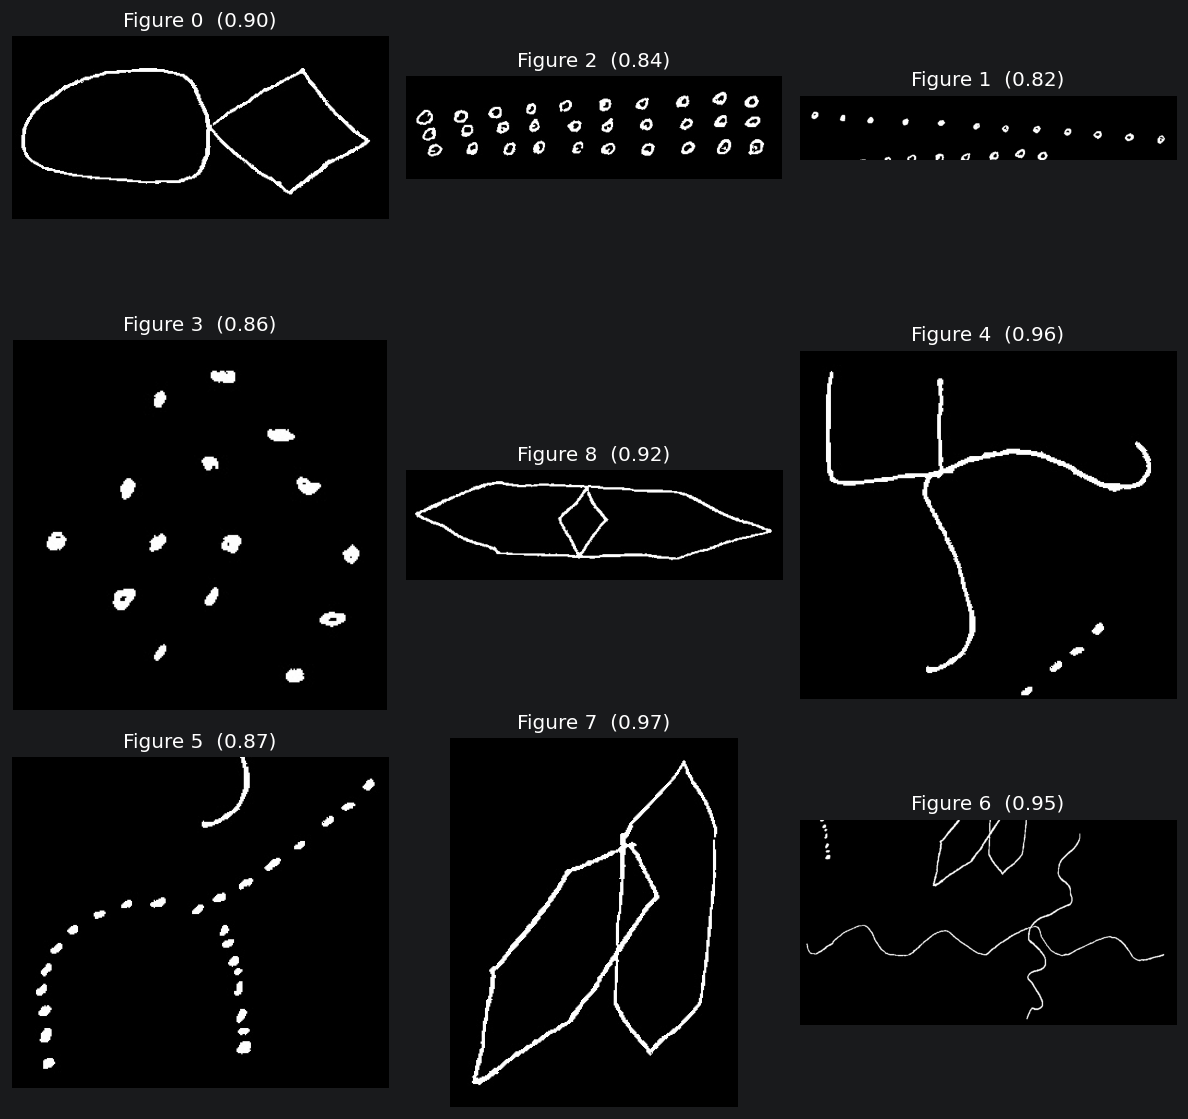

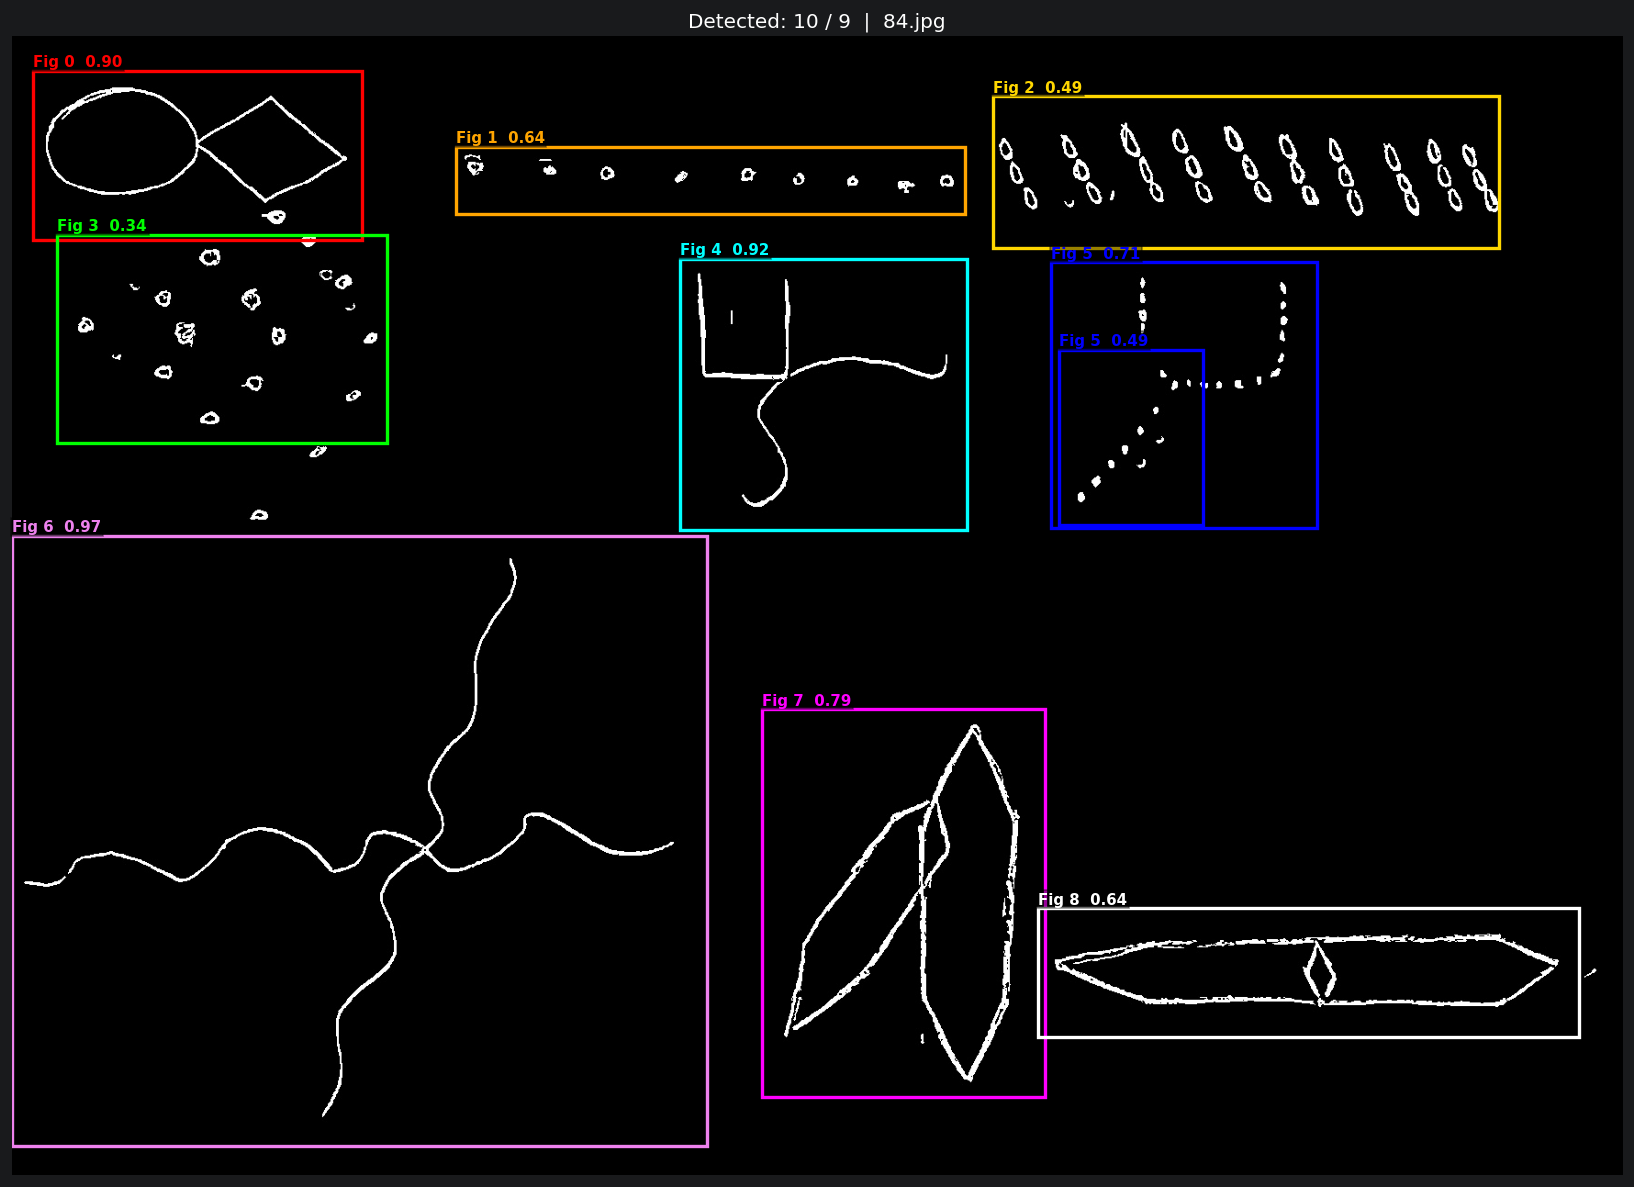

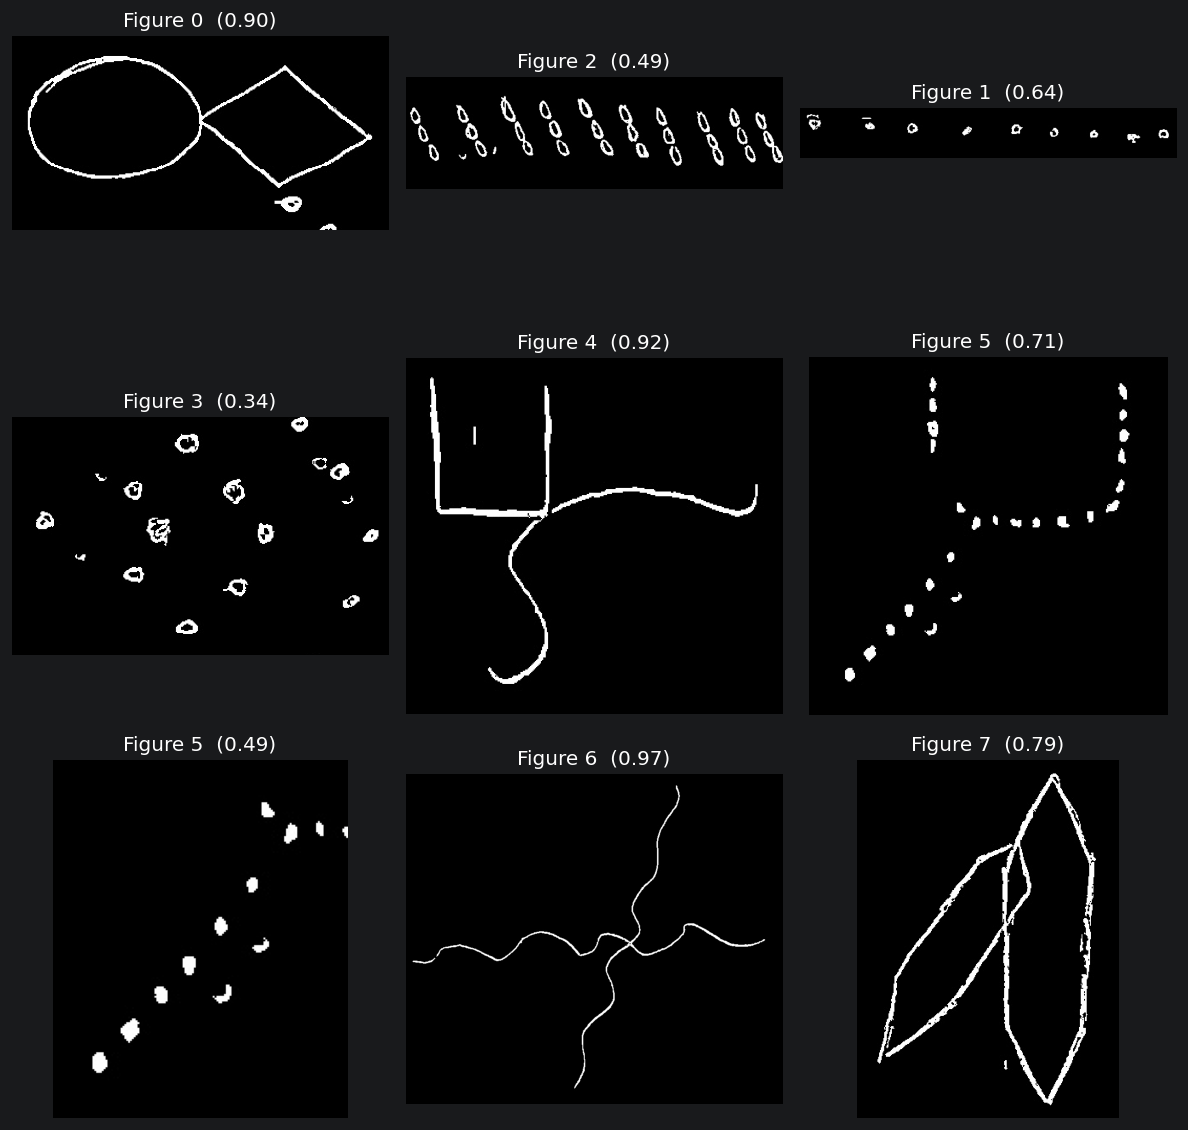

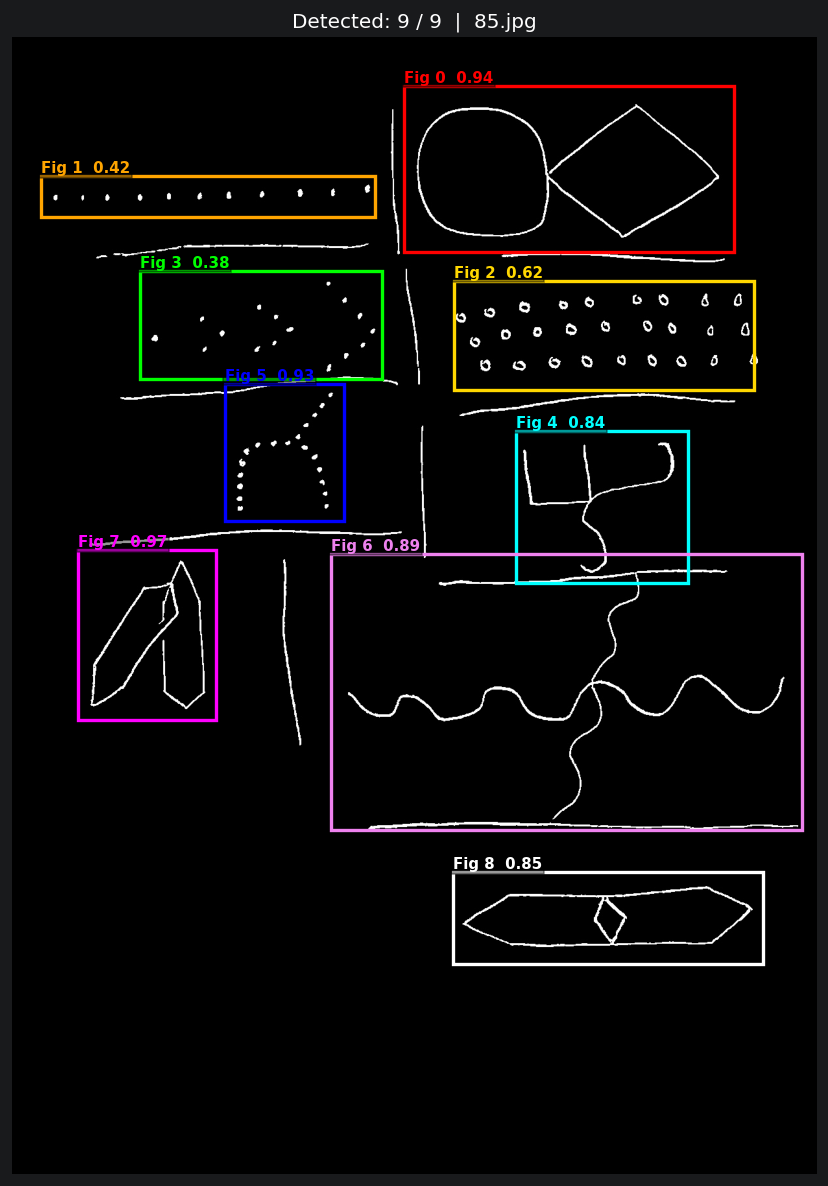

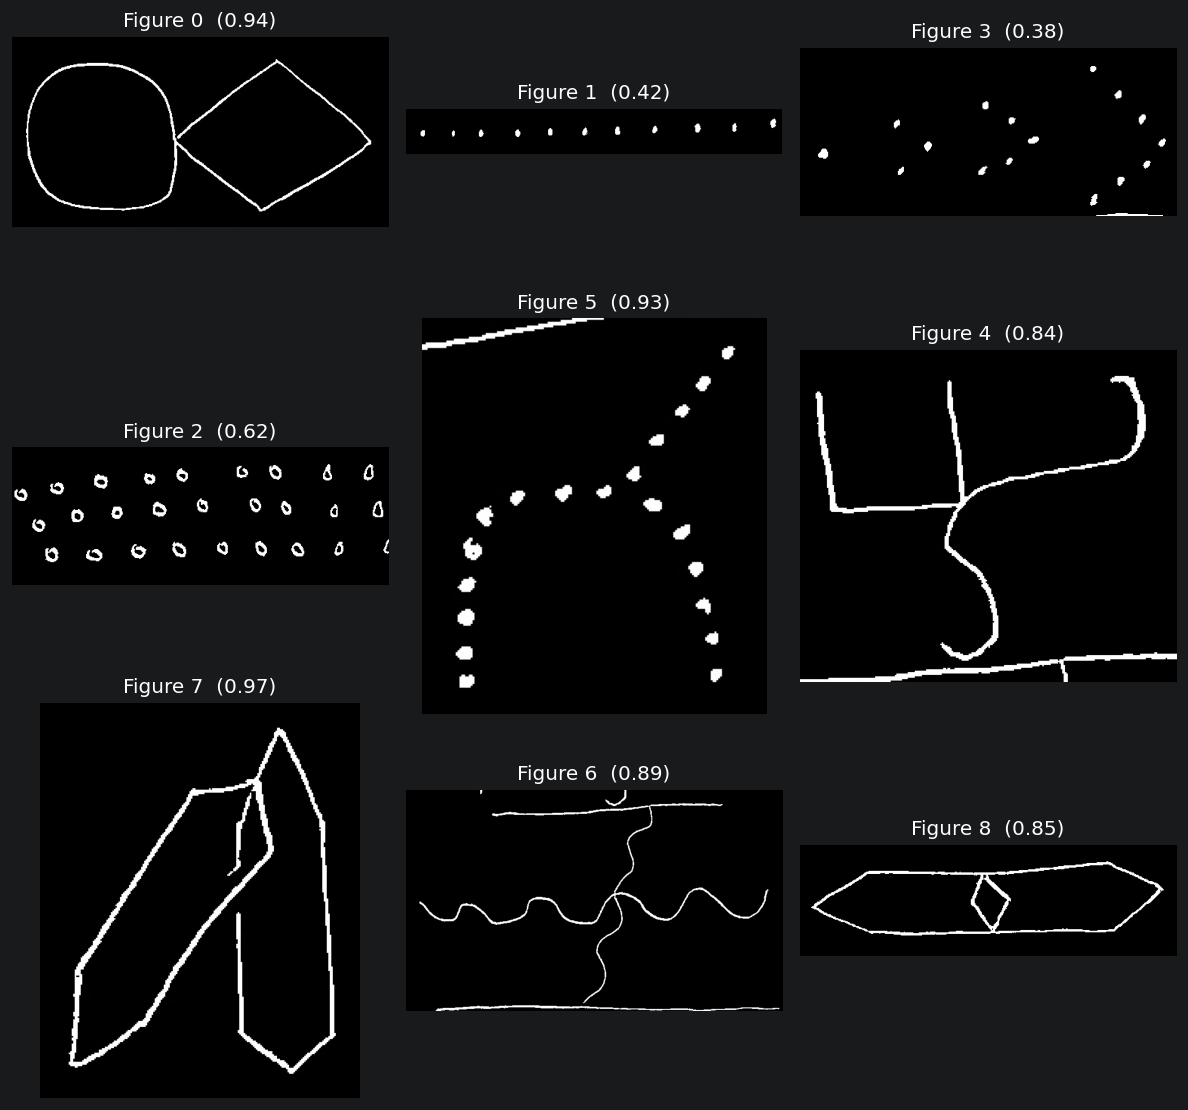

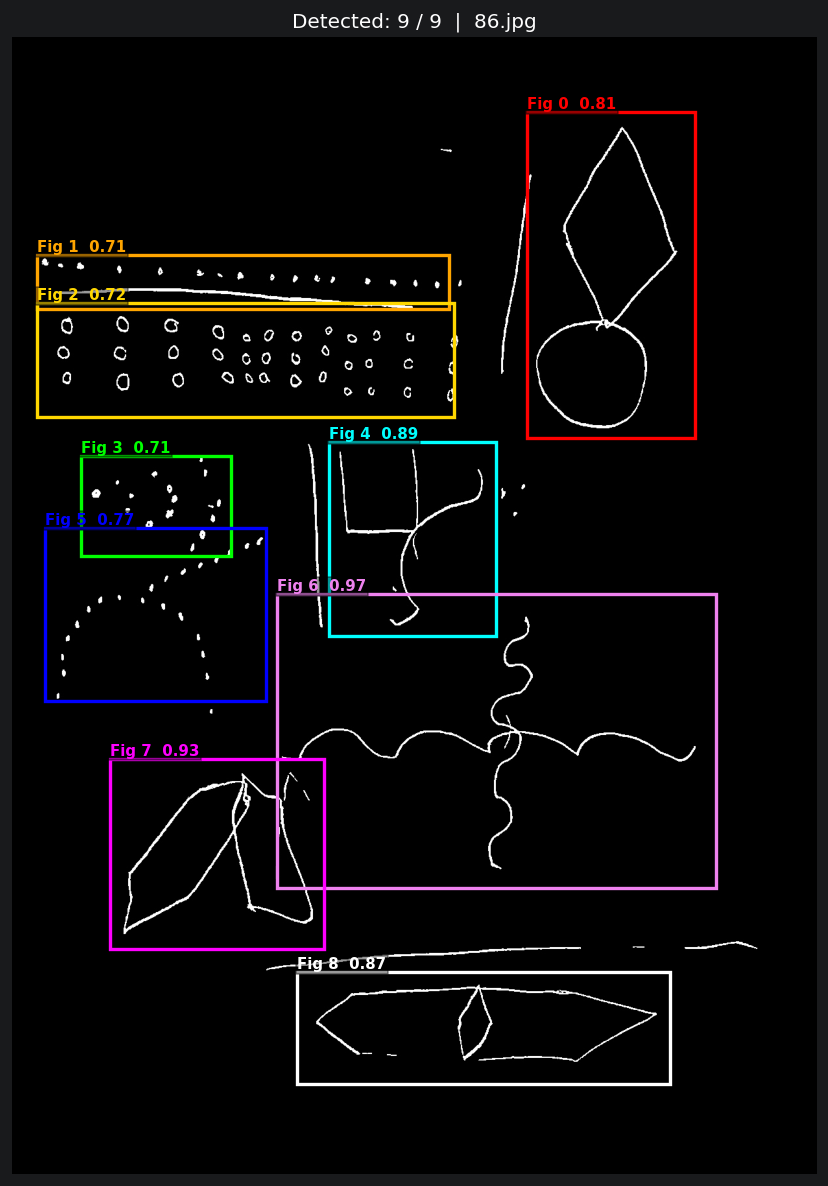

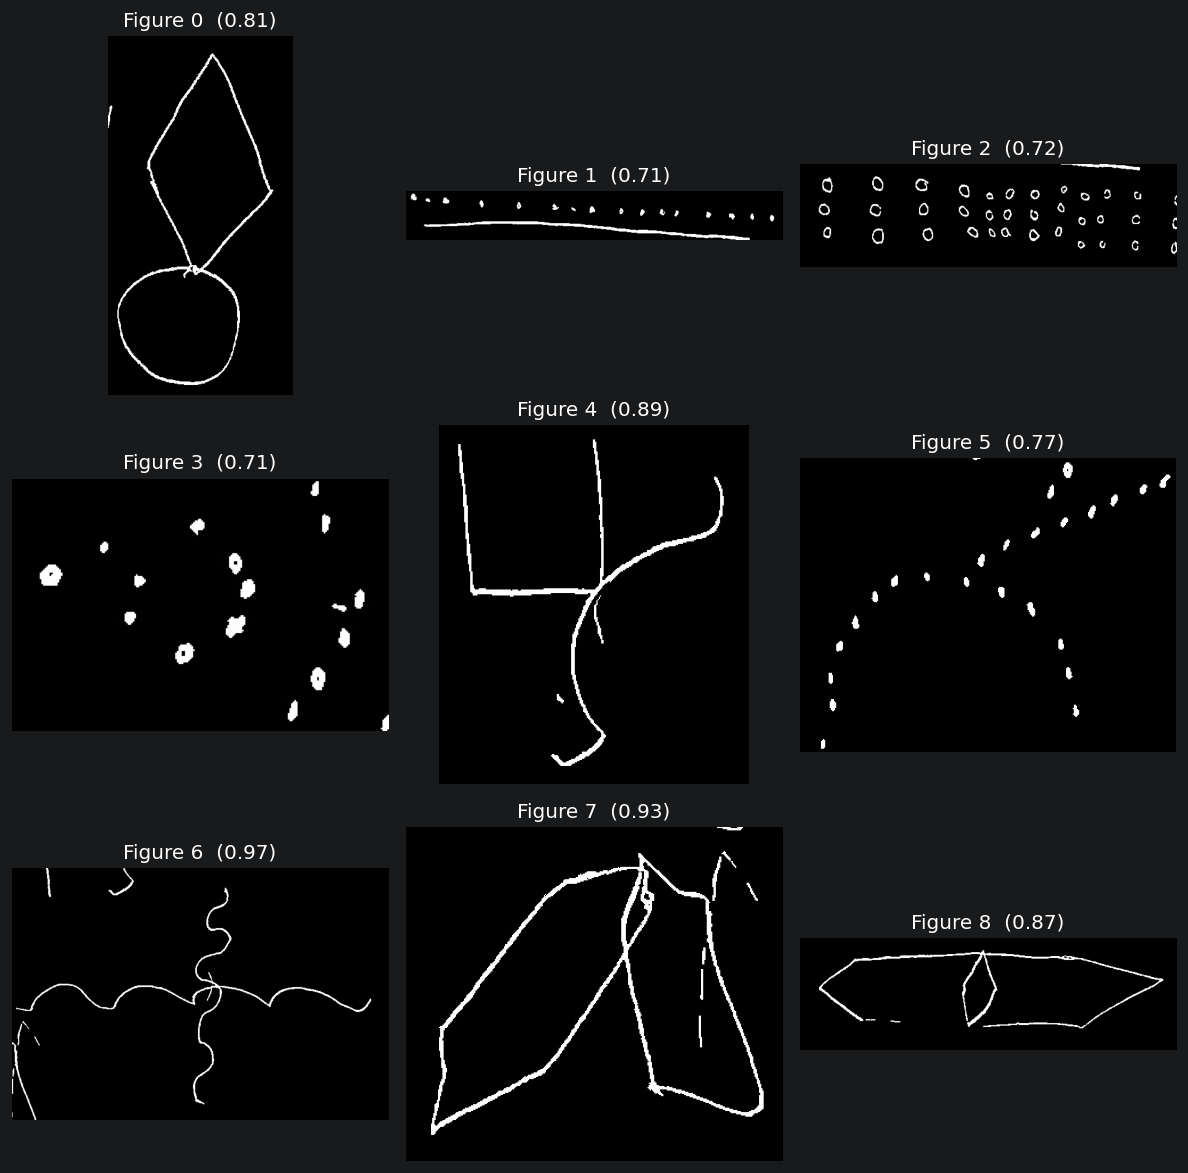

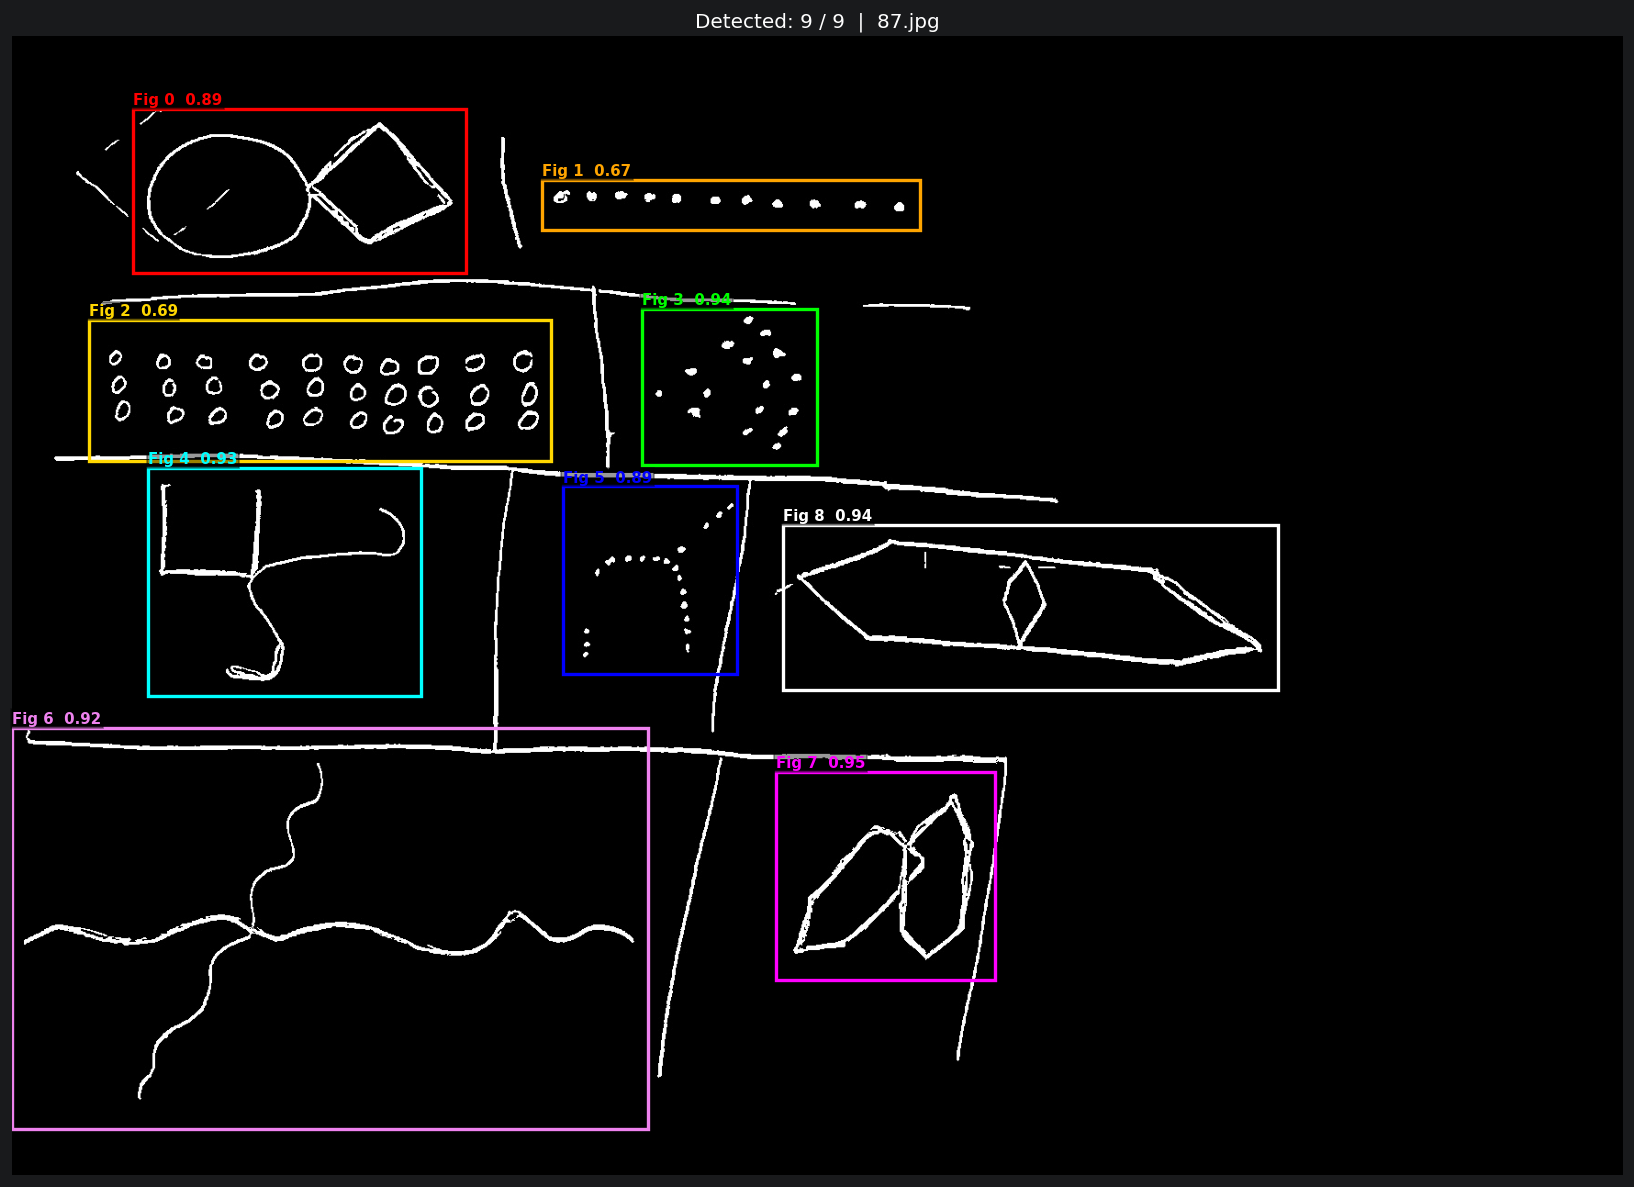

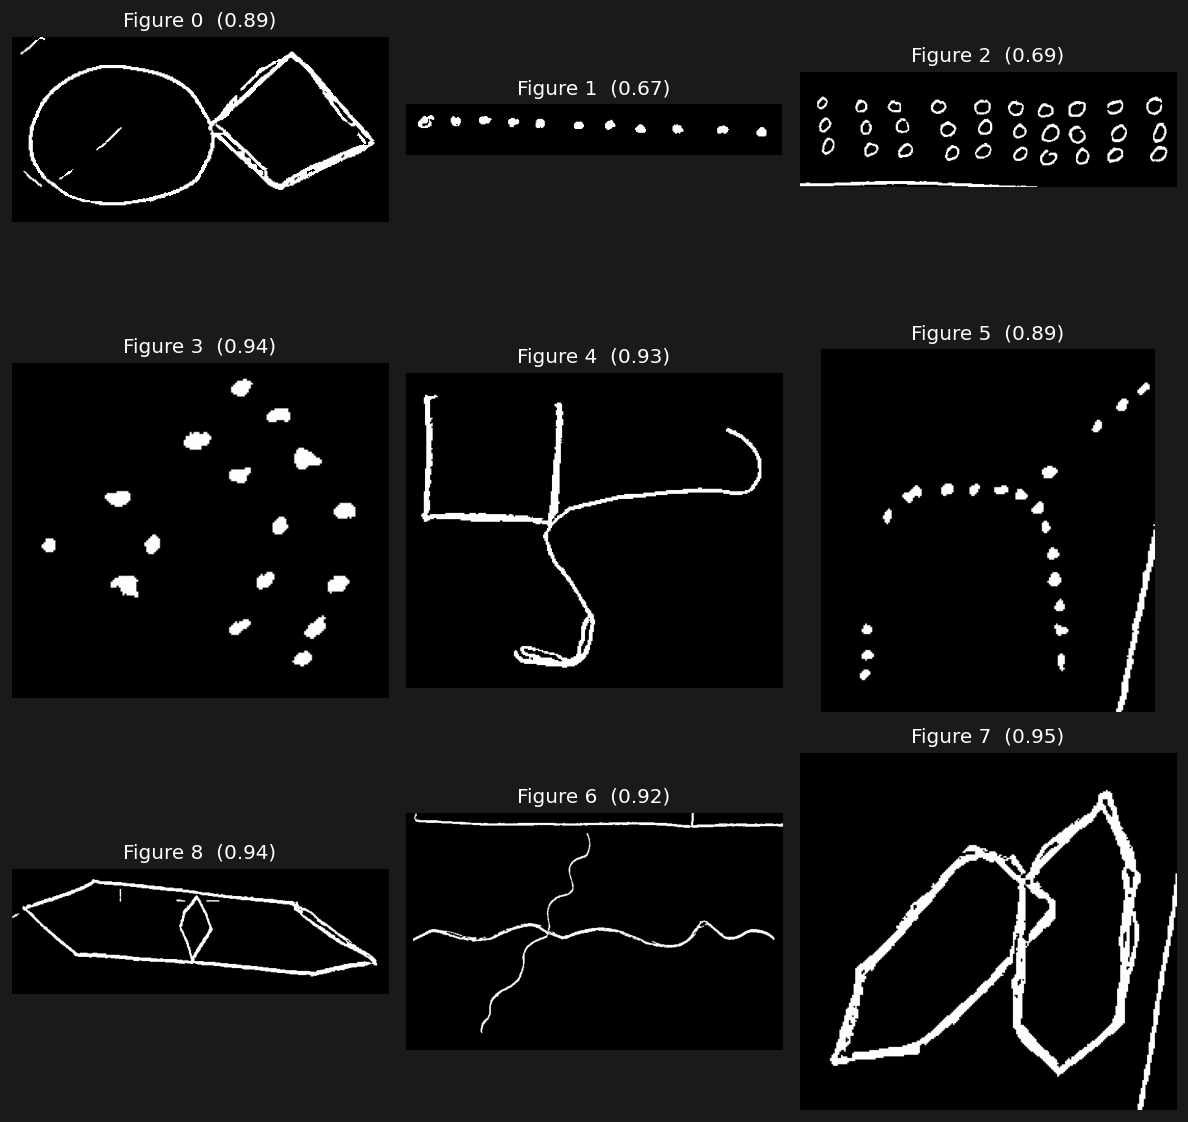

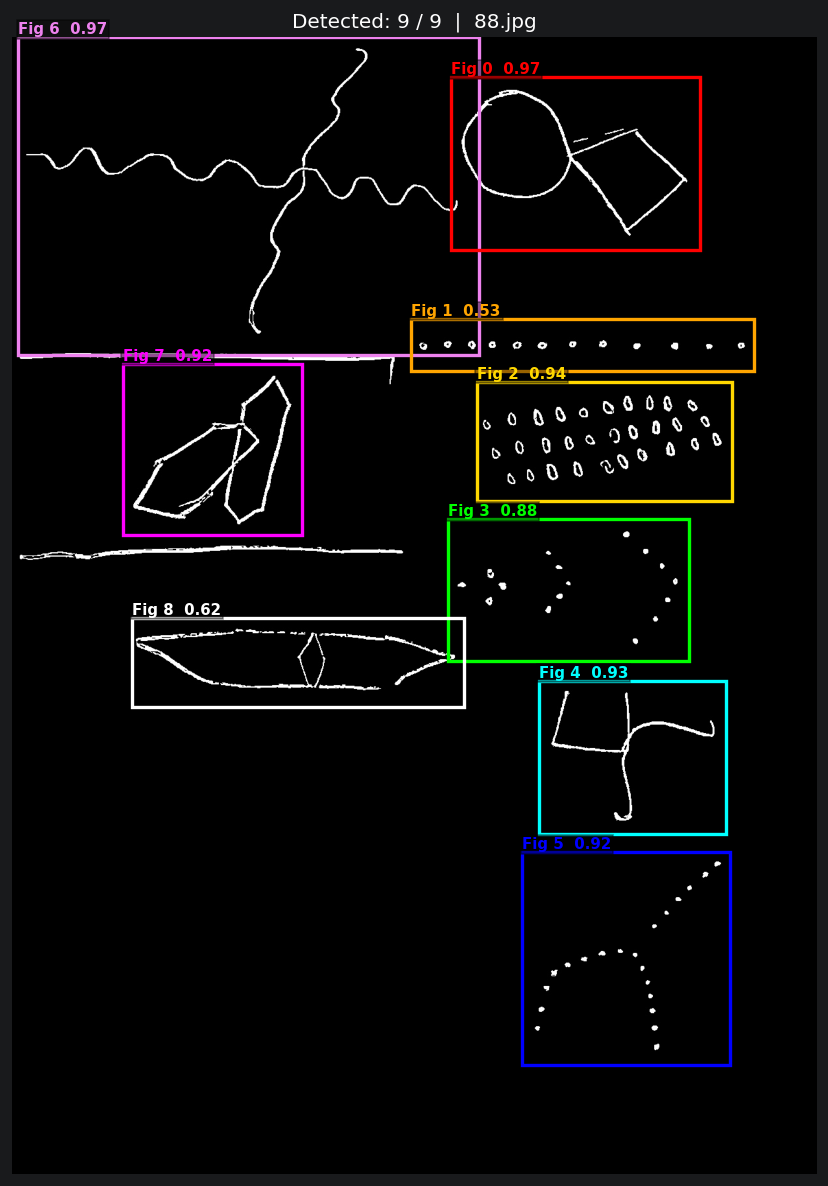

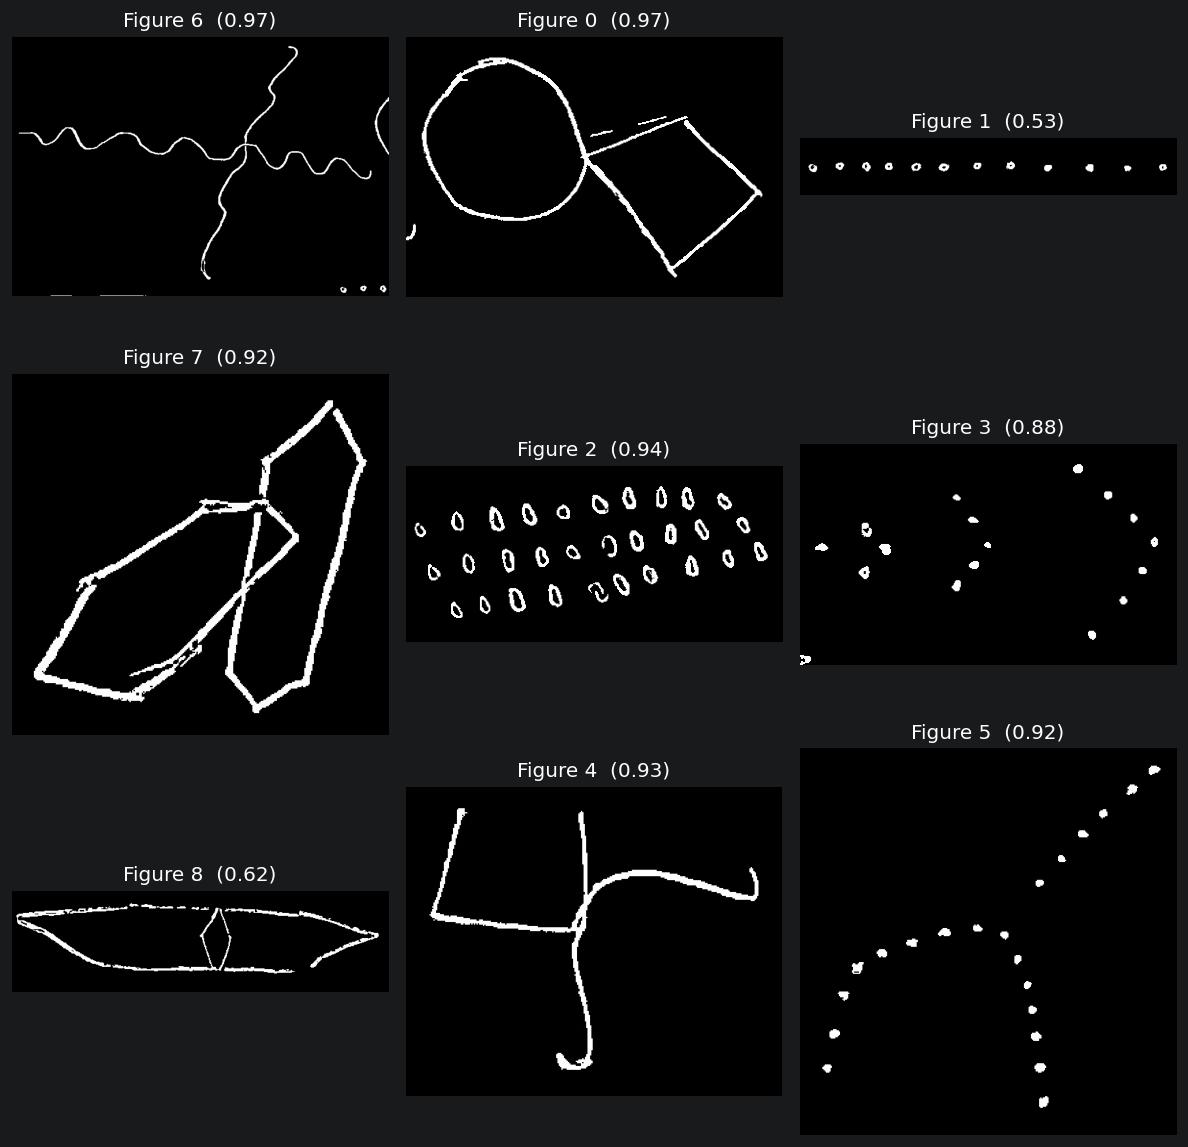

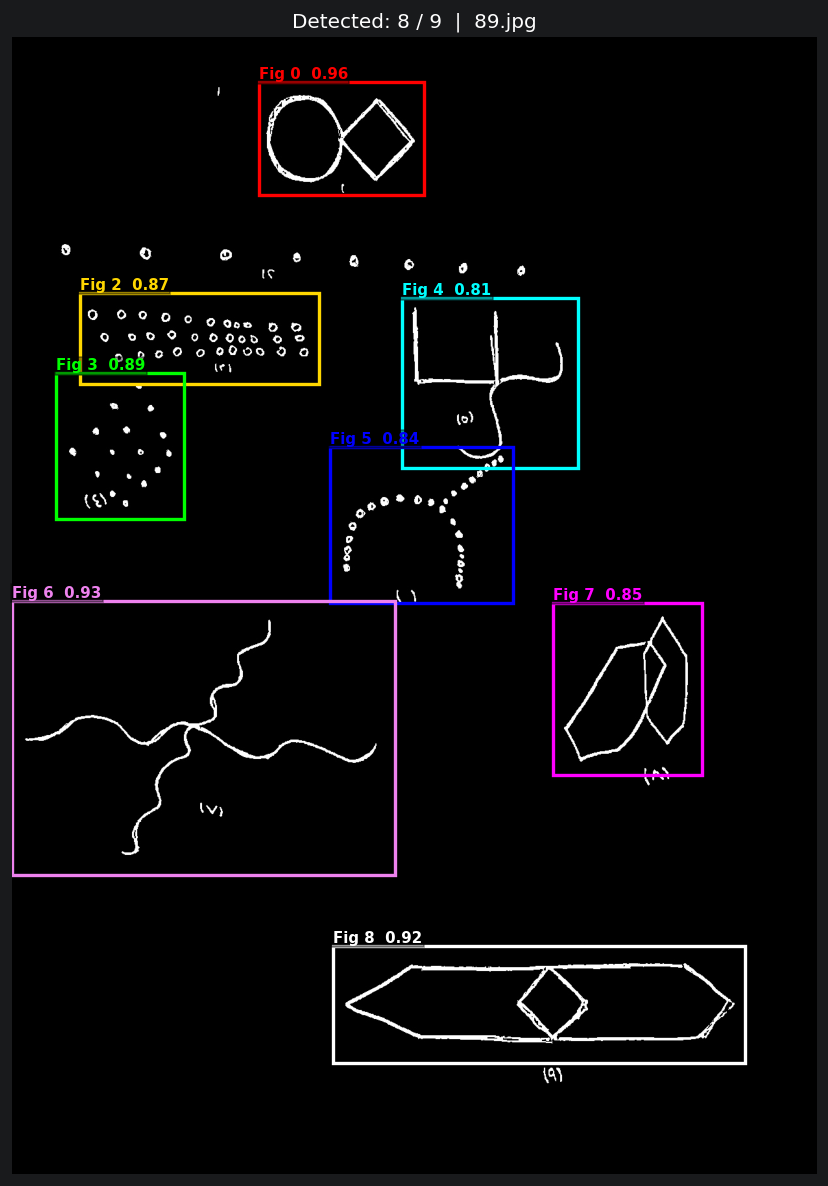

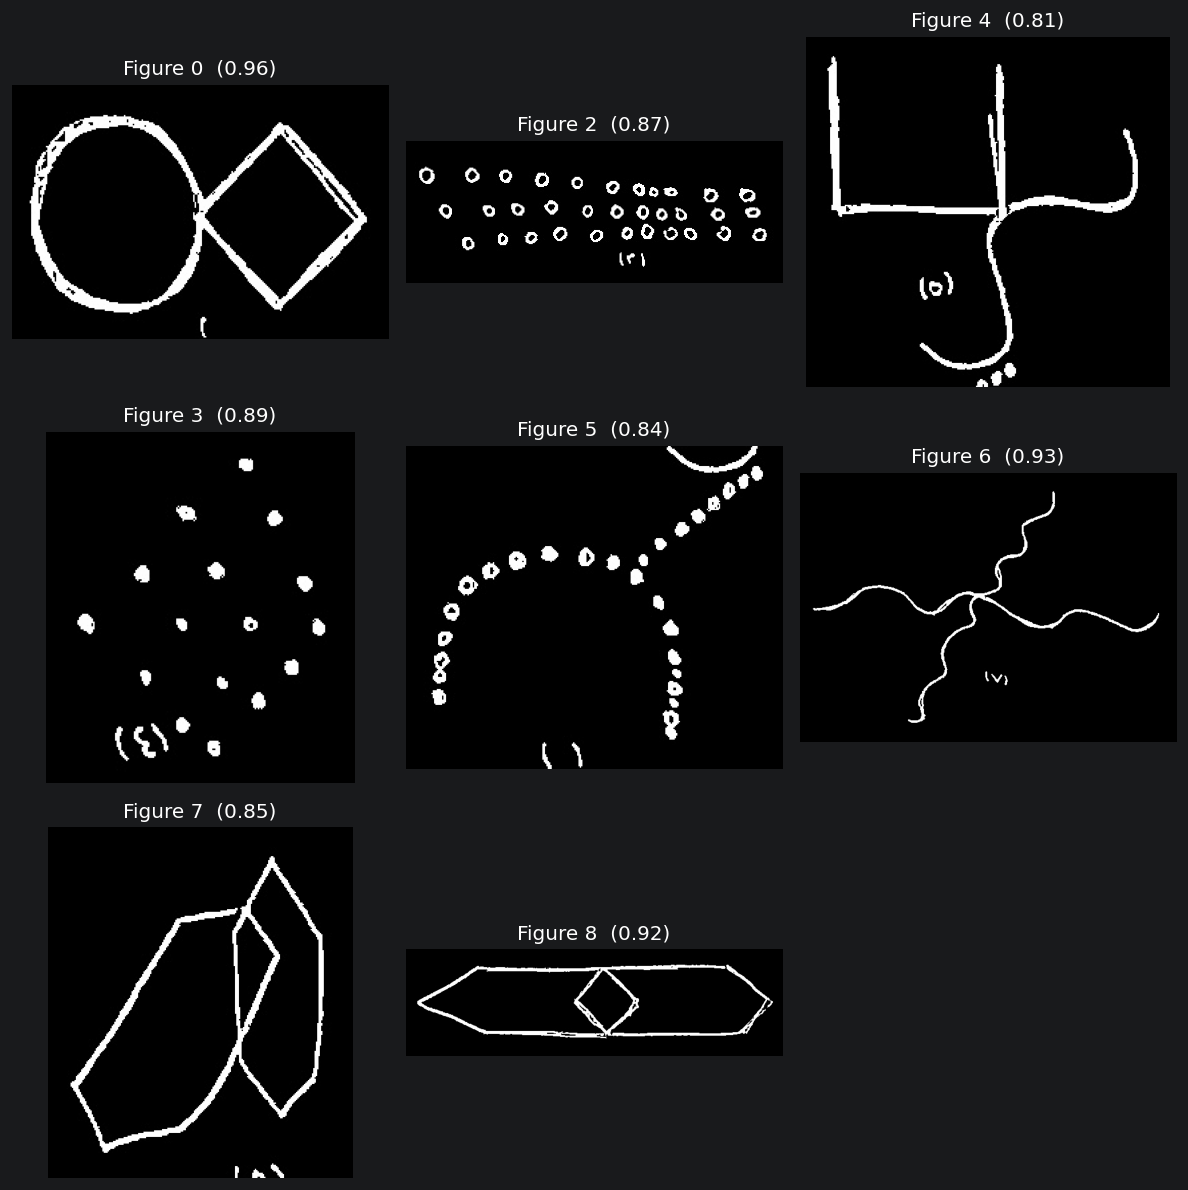


===== Inference Summary =====
 image  detected missing  avg_conf
80.jpg         9       —     0.885
81.jpg         9       —     0.802
82.jpg         9       —     0.848
83.jpg         9       —     0.898
84.jpg        10       —     0.688
85.jpg         9       —     0.760
86.jpg         9       —     0.819
87.jpg         9       —     0.868
88.jpg         9       —     0.854
89.jpg         8       1     0.885


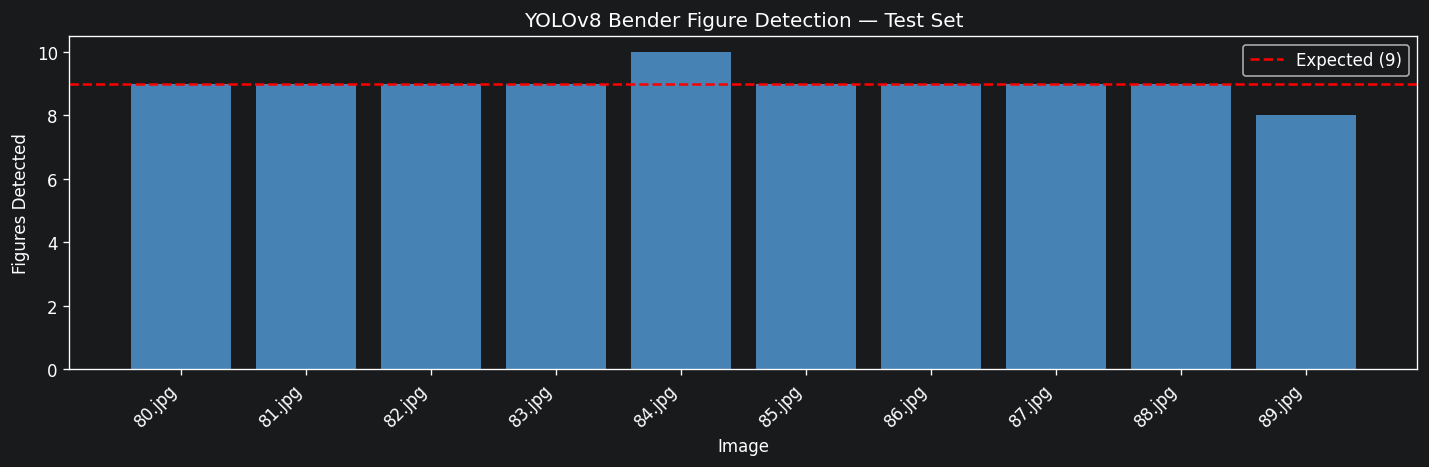

In [49]:
# CELL 7: Run inference on 10 test images + summary report
import os
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import cv2
from IPython.display import display, Image as IPImage

TEST_IMAGE_DIR = "Dataset/test"
MODEL_PATH     = "runs/detect/bender/train/weights/best.pt"
FIGURE_NAMES   = ["0", "1", "2", "3", "4", "5", "6", "7", "8"]
FIGURE_COLORS  = {
    "0": "red",    "1": "orange", "2": "gold",   "3": "lime",
    "4": "cyan",   "5": "blue",   "6": "violet",  "7": "magenta", "8": "white"
}

def show_inline(fig):
    """Render a matplotlib figure inline in PyCharm notebook output."""
    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=120, bbox_inches="tight")
    buf.seek(0)
    display(IPImage(data=buf.read()))
    plt.close(fig)

test_images = sorted([
    os.path.join(TEST_IMAGE_DIR, f)
    for f in os.listdir(TEST_IMAGE_DIR)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
])

print(f"Found {len(test_images)} test images\n")

# ── run inference ─────────────────────────────────────────────────────────────
all_results  = {}
summary_rows = []

for img_path in test_images:
    results = extract_bender_figures(img_path, model_path=MODEL_PATH)
    all_results[img_path] = results

    detected_names = results["names"]
    missing        = [n for n in FIGURE_NAMES if n not in detected_names]

    summary_rows.append({
        "image"   : os.path.basename(img_path),
        "detected": len(detected_names),
        "missing" : ", ".join(missing) if missing else "—",
        "avg_conf": round(float(np.mean(results["scores"])), 3) if results["scores"] else 0.0
    })

# ── per-image visualizations ─────────────────────────────────────────────────
for img_path, results in all_results.items():
    img     = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # — annotated full image —
    fig, ax = plt.subplots(1, 1, figsize=(14, 10))
    ax.imshow(img_rgb)
    for box, name, score in zip(results["boxes"], results["names"], results["scores"]):
        x1, y1, x2, y2 = box
        color = FIGURE_COLORS.get(name, "lime")
        rect  = patches.Rectangle(
            (x1, y1), x2 - x1, y2 - y1,
            linewidth=2, edgecolor=color, facecolor="none"
        )
        ax.add_patch(rect)
        ax.text(x1, y1 - 5, f"Fig {name}  {score:.2f}",
                color=color, fontsize=9, fontweight="bold",
                bbox=dict(facecolor="black", alpha=0.4, pad=1))
    ax.set_title(f"Detected: {len(results['boxes'])} / 9  |  {os.path.basename(img_path)}")
    ax.axis("off")
    plt.tight_layout()
    show_inline(fig)

    # — 3×3 crop grid —
    crops = results["crops"]
    if crops:
        fig2, axes = plt.subplots(3, 3, figsize=(10, 10))
        for idx, ax2 in enumerate(axes.flat):
            if idx < len(crops):
                ax2.imshow(crops[idx], cmap="gray")
                ax2.set_title(f"Figure {results['names'][idx]}  ({results['scores'][idx]:.2f})")
            ax2.axis("off")
        plt.tight_layout()
        show_inline(fig2)

# ── summary table ─────────────────────────────────────────────────────────────
summary_df = pd.DataFrame(summary_rows)
print("\n===== Inference Summary =====")
print(summary_df.to_string(index=False))

# ── bar chart ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 4))
x_pos = range(len(summary_df))
ax.bar(x_pos, summary_df["detected"], color="steelblue")
ax.axhline(9, color="red", linestyle="--", label="Expected (9)")
ax.set_xlabel("Image")
ax.set_ylabel("Figures Detected")
ax.set_title("YOLOv8 Bender Figure Detection — Test Set")
ax.set_xticks(x_pos)
ax.set_xticklabels(summary_df["image"], rotation=45, ha="right")
ax.legend()
plt.tight_layout()
show_inline(fig)